# W02 Rover World Core (design & validation)

Stepable physics core for the synthetic Aido Rover dataset. One shared latent world
(2D occupancy map + path-planned pose) drives every channel, so the 10 sensor streams
are physically coupled rather than independent random series.

The implementation is the shared module `shared_modules/rover_world.py` (single source of truth,
also imported by `W02_Preprocessing_Pipeline.ipynb` and the W5–6 RL envs). This notebook
imports it and documents the design + validates it (calibration, rollout, plots, blockage demo).

Two-layer architecture: the module is only the world core:
`world.step(action) -> 10 channels + label + info`. `obs` / `reward` / `done` are the
MDP wrapper layer, deliberately deferred to W5.

Channels (match `data/synthetic_rover_data.csv`):
`gps_lat, gps_lon, lidar_distance, battery_soc, torque_0..3, ambient_temp, anomaly_label`.

All scales are anchored to the Aido Rover product documentation:
10 Hz, patrol 0.8–1.2 m/s, LiDAR VLP-32C 200 m / 120° forward fan, RTK ±2 cm,
395 kg platform, 48 V·200 Ah (9.6 kWh) LiFePO4, AMDC `k_terrain` 0.02–0.25.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))   # repo root, to import the shared world core
from shared_modules.rover_world import RoverWorld, SITE, P_IDLE, C_TAU, DT

# ============ RUN KNOBS (adjust per use) ============
SEED     = 42       # episode RNG: faults, sensor noise, blockage positions
MAP_SEED = 6        # map/route/terrain layout (change -> a different but valid map)
N_STEPS  = 15000    # rollout length (25 min @10Hz)
# HAZARD is auto-calibrated per MAP_SEED to hit ~15% (section 4)
# ====================================================

## 1. The latent world: seeded map, terrain, waypoint DAG

`build_map(MAP_SEED)` (in `shared_modules/rover_world.py`) procedurally generates one fixed map from
a seed (different seeds → different valid layouts, used to check reward/policy robustness
across maps — not for cross-map generalization). It lays out:

- a boustrophedon main coverage cycle (`N_SWEEPS` horizontal sweeps + edge connectors);
- one rejoining detour per sweep (apex bowing into the interior, then back onto the line) —
  so `reroute` is a general skill exercised at several branch nodes, not one spot;
- mixed-shape terrain patches (circles/rects/triangles, bounded size → short crossings)
  on both main and branch edges (so a detour isn't systematically cleaner than the main
  route — `reroute` becomes a real cost/benefit choice), weighted toward rougher terrain;
- static obstacles placed by rejection-sampling so they clear every route/reroute edge
  (the rover never drives into one) — they only shape the LiDAR fan.

Terrain is checked first-match-wins, ordered by severity (mud > wet_grass > dry_grass > gravel).

## 2. LiDAR ray-cast

`cast_min(...)` synthesises the scalar `lidar_distance` by casting a forward 120° sector of
120 rays and taking the minimum range to any obstacle/wall (clipped to 200 m).
Forward-sector min (not a single beam, not 360°) keeps nearby obstacles from being missed and
makes the distribution multimodal. Analytic ray–circle and ray–segment intersection, vectorised
over rays. (Product "32-beam" is the 3D LiDAR's *vertical* channel count — unrelated to this 2D fan.)


## 3. The world core

`RoverWorld.step(action)` runs the finalised step ordering 1–10:

1. action → speed factor & branch choice (`continue` / `slow` ×0.5 / `reroute` = alternate
   branch at the next node; `raise-alert` / `return-to-base` have no motion effect here)
2. pose is the exact point on the current DAG edge (arc-length follower — the path lies
   *on* the planned route, no capture radius / corner-cutting); heading = edge direction,
   so the rover turns in place at each node (0 m turning radius — skid/mecanum)
3. terrain lookup at the current pose
4. fault state machine → label (start prob `hazard · slip_weight(terrain)`; else decrement TTL).
   A `FAULT_COOLDOWN` refractory window after each event blocks back-to-back chaining
   (otherwise a fault slows the rover inside a high-slip patch → re-triggers → "slip trap").
5. torque: terrain-demanded base + correlated 4-wheel noise + fault signature
   (slip = one wheel spikes, others shed → anti-correlation; stuck = all wheels rise)
6. advance arc-length along the edge by the fault-reduced speed (slip `v·(1−0.7s)`, stuck `v·(1−s)`);
   if a temporary blockage sits ahead on this edge, halt just before it (can't cross)
7. else cross to the next node when the edge is consumed (carry the remainder; branch chosen by action)
8. battery: `discharge = α·(P_idle + C_τ·Στ)·dt`, coupled to torque (current proxy)
9. LiDAR: ray-cast min (incl. any blockage as a visible obstacle) + range-dependent AR(1) noise + max-range dropout
10. GPS (xy→lat/lon + RTK noise, multipath near structures) + ambient temp

Severity `s ~ Beta(2,5)` (skewed-mild) is a latent per-event scalar, not a channel.
LiDAR carries no fault imprint (kept an independent spatial observation). Faults are
ego-centric mechanical self-faults — no spatial location.

Temporary blockages & `reroute` (default OFF): when `blockages=True`, a per-episode
seeded obstacle may sit on a branchable edge; it is LiDAR-visible and halts a rover
that drives into it. `reroute` = take the alternate branch to get around it and rejoin
(escalation: main blocked + branch clear → reroute; both blocked → raise-alert). Blockages
are OFF for the W2 detection stream and ON for W5 RL. Decision-only quantities the sensors
can't see — `node, target, route_progress, next_main_block_dist, branch_block_dist, halted`
— are exposed via `info` for the W5 wrapper to assemble `position_summary` (not channels).

(Implementation of §1–§3 lives in `shared_modules/rover_world.py`; the cells below import and exercise it.)

## 4. Calibrate the hazard knob to an 85/15 split (per map)

The 85/15 requirement applies to the W2 supervised dataset (fixed scripted policy +
fixed seed → deterministic), not to the W5 RL env. Terrain exposure varies by `MAP_SEED`,
so we auto-calibrate `hazard_intensity` for the chosen map: drive the `continue` policy
over a grid and pick the value whose realised anomaly fraction is closest to 15% (and in
[14%, 16%]). Temporal clustering is automatic — each fault is a multi-step burst on rough ground.


In [2]:
def realized_rate(hz, seed=SEED, n=N_STEPS, map_seed=MAP_SEED):
    w = RoverWorld(hazard_intensity=hz, seed=seed, total_steps=n, map_seed=map_seed)
    return float(np.mean([w.step(0)["anomaly_label"] for _ in range(n)]))

grid = np.round(np.arange(0.03, 0.13, 0.01), 3)
rates = {float(h): realized_rate(h) for h in grid}
for h in grid:
    print(f"hazard={h:.2f} -> anomaly rate {rates[h]*100:5.2f}%")

in_band = [h for h in rates if 0.14 <= rates[h] <= 0.16]
HAZARD = float(min(in_band or rates, key=lambda h: abs(rates[h] - 0.15)))
print(f"\nMAP_SEED={MAP_SEED}: chosen HAZARD={HAZARD:.3f} -> {rates[HAZARD]*100:.2f}% "
      f"({'in band' if in_band else 'closest (widen grid or change MAP_SEED)'})")

hazard=0.03 -> anomaly rate 11.60%
hazard=0.04 -> anomaly rate 13.31%
hazard=0.05 -> anomaly rate 15.05%
hazard=0.06 -> anomaly rate 15.27%
hazard=0.07 -> anomaly rate 17.87%
hazard=0.08 -> anomaly rate 19.19%
hazard=0.09 -> anomaly rate 19.29%
hazard=0.10 -> anomaly rate 19.42%
hazard=0.11 -> anomaly rate 20.25%
hazard=0.12 -> anomaly rate 22.57%

MAP_SEED=6: chosen HAZARD=0.050 -> 15.05% (in band)


## 5. Sanity rollout & scale checks

Drive the core for `N_STEPS` with the `continue` policy, assemble the channel frame,
and confirm every channel sits at a physically plausible scale.


In [3]:
world = RoverWorld(hazard_intensity=HAZARD, seed=SEED, total_steps=N_STEPS, map_seed=MAP_SEED)
rows = [world.step(0) for _ in range(N_STEPS)]

CHANNELS = ["gps_lat", "gps_lon", "lidar_distance", "battery_soc",
            "torque_0", "torque_1", "torque_2", "torque_3",
            "ambient_temp", "anomaly_label"]
df = pd.DataFrame([{c: r[c] for c in CHANNELS} for r in rows])
info = pd.DataFrame([r["info"] for r in rows])

lab = df["anomaly_label"].values.astype(bool)
tau = df[["torque_0", "torque_1", "torque_2", "torque_3"]].values
print(f"rows               : {len(df)}  ({DT*len(df)/60:.1f} min real time @10Hz)")
print(f"anomaly rate       : {lab.mean()*100:.2f}%  ({lab.sum()} steps)")
print(f"battery_soc        : 100.0 -> {df.battery_soc.iloc[-1]:.1f}%")
print(f"lidar_distance (m) : min {df.lidar_distance.min():.1f} / med "
      f"{df.lidar_distance.median():.1f} / max {df.lidar_distance.max():.1f}")
print(f"torque normal (Nm) : mean {tau[~lab].mean():.1f} / p95 {np.percentile(tau[~lab],95):.1f}")
print(f"torque anomaly(Nm) : mean {tau[lab].mean():.1f} / max {tau[lab].max():.1f}")
p = P_IDLE + C_TAU * tau.sum(1)
print(f"power normal/anom  : {p[~lab].mean():.0f} / {p[lab].mean():.0f} W "
      f"(ratio {p[lab].mean()/p[~lab].mean():.2f})")
print(f"terrain visits     : {info.terrain.value_counts().to_dict()}")
print(f"fault events (type): {info[info.fault.notna()].fault.value_counts().to_dict()}")
df.head()

rows               : 15000  (25.0 min real time @10Hz)
anomaly rate       : 15.05%  (2258 steps)
battery_soc        : 100.0 -> 43.5%
lidar_distance (m) : min 6.1 / med 23.1 / max 200.0
torque normal (Nm) : mean 14.0 / p95 49.5
torque anomaly(Nm) : mean 39.7 / max 63.6
power normal/anom  : 1536 / 2152 W (ratio 1.40)
terrain visits     : {'asphalt': 8705, 'dry_grass': 2077, 'wet_grass': 2044, 'mud': 1302, 'gravel': 872}
fault events (type): {'slip': 1369, 'stuck': 889}


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,anomaly_label
0,1.350180,103.800181,23.043506,99.996872,6.567591,6.292370,6.653708,5.726357,27.914696,0
1,1.350180,103.800181,23.020280,99.993786,5.858284,5.374434,5.397751,5.567837,27.996264,0
2,1.350180,103.800182,23.021369,99.990666,6.117484,5.948414,6.500591,6.072725,28.045595,0
3,1.350179,103.800183,23.079684,99.987552,5.822105,6.160301,5.923151,6.274306,28.068829,0
4,1.350180,103.800184,23.091031,99.984460,5.711312,5.763550,5.464508,5.651558,28.011784,0


### Trajectory over the latent map

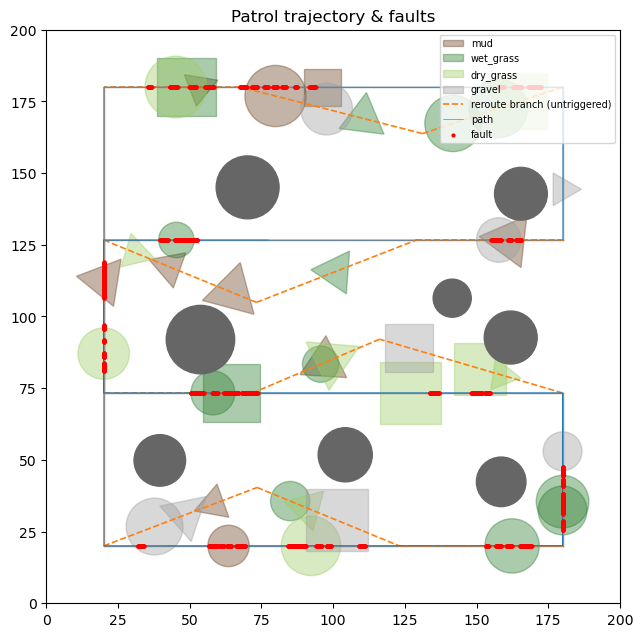

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
m = world.m
tcol = {"mud": "#6b4423", "wet_grass": "#2e7d32", "dry_grass": "#9ccc65", "gravel": "#9e9e9e"}
seen = set()
for z in m["zones"]:                      # terrain patches (mixed shapes)
    name = z["name"]; lbl = name if name not in seen else None; seen.add(name)
    if z["shape"] == "rect":
        ax.add_patch(plt.Rectangle((z["x0"], z["y0"]), z["x1"] - z["x0"], z["y1"] - z["y0"],
                                   alpha=0.40, color=tcol[name], label=lbl))
    elif z["shape"] == "circle":
        ax.add_patch(plt.Circle(z["c"], z["r"], alpha=0.40, color=tcol[name], label=lbl))
    else:
        ax.add_patch(plt.Polygon(z["pts"], alpha=0.40, color=tcol[name], label=lbl))
for cx, cy, r in m["obstacles"]:          # static obstacles
    ax.add_patch(plt.Circle((cx, cy), r, color="0.4"))
# waypoint DAG: main coverage cycle (solid) + per-sweep reroute branches (dashed, untriggered)
cyc = [0]; nn = m["route"][0]
while nn != 0:
    cyc.append(nn); nn = m["route"][nn]
for k in range(len(cyc)):
    (x0, y0), (x1, y1) = m["nodes"][cyc[k]], m["nodes"][cyc[(k + 1) % len(cyc)]]
    ax.plot([x0, x1], [y0, y1], color="0.55", lw=1.0, zorder=1)
for i, (A, B, ap, rj) in enumerate(m["branches"]):
    for j, (u, v) in enumerate([(A, ap), (ap, rj), (rj, B)]):
        (x0, y0), (x1, y1) = m["nodes"][u], m["nodes"][v]
        ax.plot([x0, x1], [y0, y1], color="C1", lw=1.2, ls="--", zorder=1,
                label="reroute branch (untriggered)" if (i == 0 and j == 0) else None)
ax.plot(info.x, info.y, lw=0.4, color="C0", label="path")
ax.scatter(info.x[lab], info.y[lab], s=4, color="red", label="fault", zorder=3)
ax.set(xlim=(0, SITE), ylim=(0, SITE), aspect="equal", title="Patrol trajectory & faults")
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout(); plt.show()

### Channel time series (anomaly steps shaded)

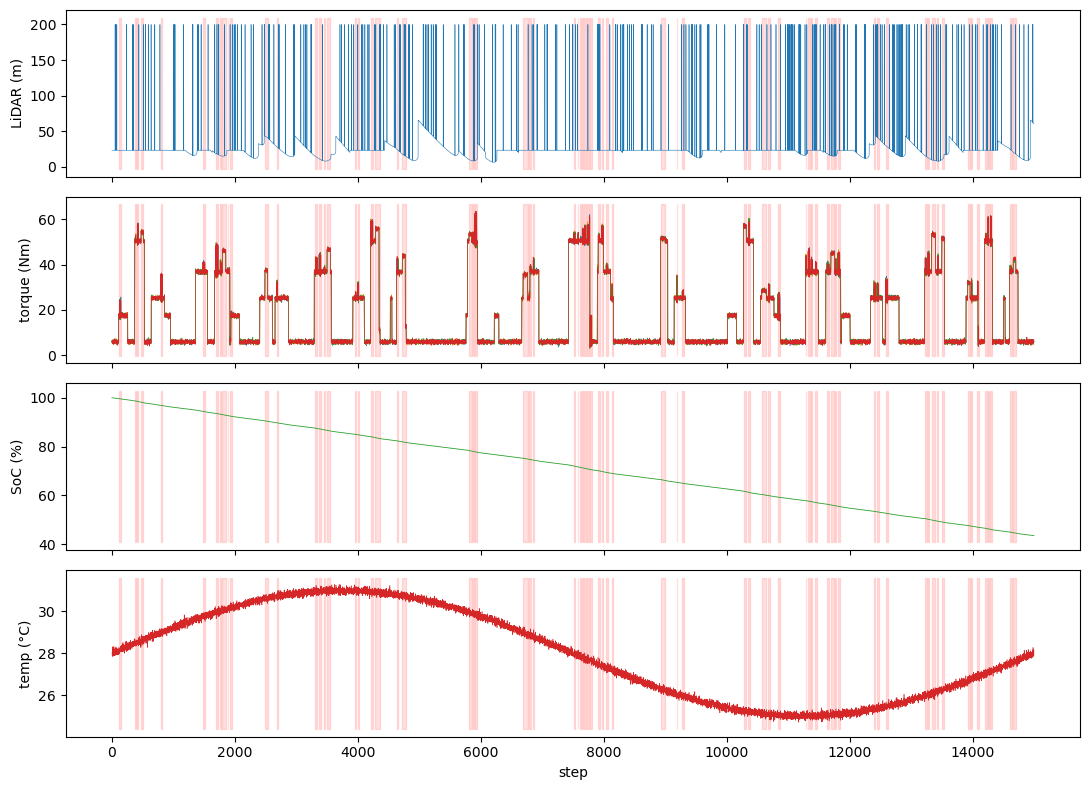

In [5]:
fig, axs = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
t = np.arange(len(df))
axs[0].plot(t, df.lidar_distance, lw=0.4); axs[0].set_ylabel("LiDAR (m)")
axs[1].plot(t, tau, lw=0.4); axs[1].set_ylabel("torque (Nm)")
axs[2].plot(t, df.battery_soc, lw=0.6, color="C2"); axs[2].set_ylabel("SoC (%)")
axs[3].plot(t, df.ambient_temp, lw=0.4, color="C3"); axs[3].set_ylabel("temp (°C)")
axs[3].set_xlabel("step")
for ax in axs:
    ax.fill_between(t, *ax.get_ylim(), where=lab, color="red", alpha=0.12, step="mid")
plt.tight_layout(); plt.show()

### Fault severity distribution

Severity is a latent per-event scalar (`info.sev`, not a channel), so it validates the
fault model here rather than in the dataset. Channel (lidar/torque) distributions live in
the dataset-validation section of `W02_Preprocessing_Pipeline.ipynb`.


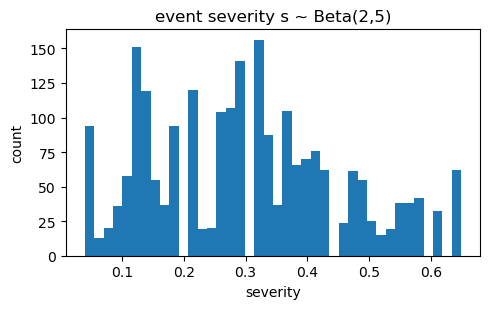

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.hist(info.sev[lab], bins=40)
ax.set(title="event severity s ~ Beta(2,5)", xlabel="severity", ylabel="count")
plt.tight_layout(); plt.show()

## 6. Temporary blockages & reroute (RL scenario, blockages enabled)

Blockages are OFF above (byte-identical W2 stream). Here we force them on to show the
`reroute` mechanic the W5 policy will learn: blockages on branchable sweep legs halt a
rover that keeps `continue`, but are avoided by `reroute` (which takes each sweep's detour).

blockages this episode: {(2, 3): 89.0, (4, 5): 90.1, (6, 7): 62.3}
continue: halted 11888 steps; nodes visited [np.int64(0), np.int64(1), np.int64(2)]
reroute : halted 0 steps; nodes visited [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


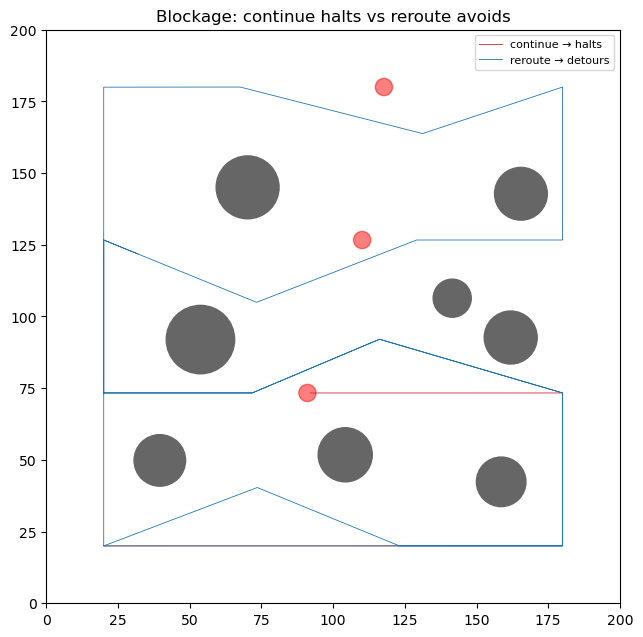

In [7]:
def rollout(policy_action):
    w = RoverWorld(hazard_intensity=HAZARD, seed=SEED, map_seed=MAP_SEED, blockages=True,
                   p_block=1.0, p_full_block=0.0)   # force a blockage on every branchable leg
    return w, [w.step(policy_action) for _ in range(N_STEPS)]

w_c, rc = rollout(0)   # continue -> drives into the first blockage and halts
w_r, rr = rollout(2)   # reroute  -> takes each detour branch
ic = pd.DataFrame([r["info"] for r in rc])
ir = pd.DataFrame([r["info"] for r in rr])
print("blockages this episode:", {k: round(v[0], 1) for k, v in w_c.blockages.items()})
print(f"continue: halted {int(ic.halted.sum())} steps; nodes visited {sorted(ic.node.unique())}")
print(f"reroute : halted {int(ir.halted.sum())} steps; nodes visited {sorted(ir.node.unique())}")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
m = w_c.m
for cx, cy, r in m["obstacles"]:
    ax.add_patch(plt.Circle((cx, cy), r, color="0.4"))
for e in w_c.blockages:                      # blockage(s) in red
    bx, by, br = w_c._blk_xy(e)
    ax.add_patch(plt.Circle((bx, by), br, color="red", alpha=0.5))
ax.plot(ic.x, ic.y, lw=0.6, color="C3", label="continue → halts")
ax.plot(ir.x, ir.y, lw=0.6, color="C0", label="reroute → detours")
ax.set(xlim=(0, SITE), ylim=(0, SITE), aspect="equal", title="Blockage: continue halts vs reroute avoids")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

---
Scope: this notebook demonstrates the world core (`shared_modules/rover_world.py`). Producing the W2
CSV (`W02_Preprocessing_Pipeline.ipynb` drives `world.step` and dumps channels+label), the
offline `rover_transitions.csv` (`W02_Sequence_and_RL_Scaffolding.ipynb`), and the W5 Gymnasium
wrapper (`obs`/`reward`/`done`) build on top of this `step`.